In [10]:
import csv
import sys
import os

IN_COLAB = "COLAB_GPU" in os.environ
if IN_COLAB:
    !git clone https://github.com/sinskid/deep_learning_project.git
    %cd deep_learning_project
    !pip install -r requirements.txt

repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_path not in sys.path:
    sys.path.append(repo_path)

import python.data as d
from python.models import get_cnn , get_vit, accuracy
from python.utils import setup_dirs

import torch
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt

fatal: destination path 'deep_learning_project' already exists and is not an empty directory.
/content/deep_learning_project


In [11]:
# Set up directories for logs
paths = setup_dirs()
csv_path = os.path.join(paths["logs"], "evaluation.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["dataset", "cnn", "vit"])

def log_result(dataset_name, cnn_acc, vit_acc):
    with open(csv_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([dataset_name, f"{cnn_acc:.3f}", f"{vit_acc:.3f}"])

In [13]:
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
# Initialize the CNN model and move it to the appropriate device
model_cnn = get_cnn().to(device)

# Initialize the ViT model and move it to the appropriate device
model_vit = get_vit().to(device)

# CNN
model_cnn.load_state_dict(torch.load(os.path.join(paths["models"], "cnn_model.pth"), map_location=device))
model_cnn.eval()

# ViT
model_vit.load_state_dict(torch.load(os.path.join(paths["models"], "vit_model.pth"), map_location=device))
model_vit.eval()

cuda


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


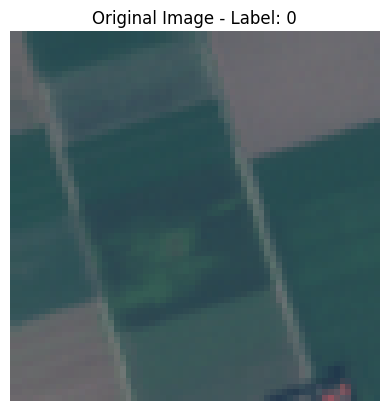

In [16]:
# Depend de CPU ou GPU
num_workers = 2
batch_size = 32

# Image dataset
image_dataloader_test = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "image", data_type = "test")
to_pil = ToPILImage()
image, label = to_pil(next(iter(image_dataloader_test))[0][0]), next(iter(image_dataloader_test))[1][0].item()

plt.imshow(image)
plt.title(f"Original Image - Label: {label}")
plt.axis('off')
plt.savefig(os.path.join(paths["images"], "original_image.png"))
plt.show()

# Datasets sans effets
cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "cnn", data_type = "test")
vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "vit", data_type = "test")

In [17]:
# Datasets sans effets
cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "cnn", data_type = "test")
vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, model_name = "vit", data_type = "test")

# Test accuracy CNN sans effets
acc_cnn = accuracy(cnn_dataloader, model_cnn, device)
print(f"Test Accuracy (CNN): {acc_cnn:.4f}")

# Test accuracy ViT sans effets
acc_vit = accuracy(vit_dataloader, model_vit, device)
print(f"Test Accuracy (ViT): {acc_vit:.4f}")

log_result("no effect", acc_cnn, acc_vit)

Test Accuracy (CNN): 0.9811
Test Accuracy (ViT): 0.9754


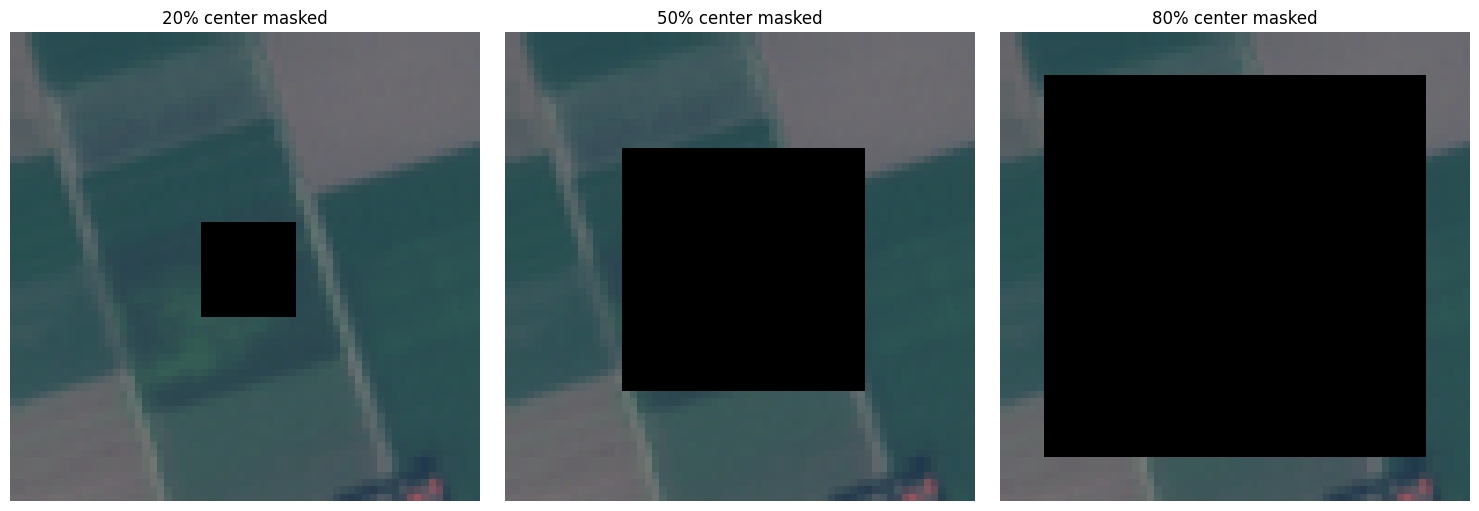

KeyboardInterrupt: 

In [19]:
# Datasets avec effets masquage du centre de l'image
mask_percent = [0.2, 0.5, 0.8]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boucle sur les différents pourcentages de masque
for ax, mask in zip(axes, mask_percent):
    # Modifier l'image en appliquant un effet
    modified_image = d.apply_center_mask(image, mask)
    ax.imshow(modified_image)
    ax.axis('off')  # Masquer les axes
    ax.set_title(f"{int(mask*100)}% center masked")
plt.tight_layout()
plt.savefig(os.path.join(paths["images"], "center_masked_images.png"))
plt.show()

for mask in mask_percent:

    # Créer des dataloaders avec l'effet de masque centré
    center_mask_effects = {"center_mask": mask}
    cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=center_mask_effects)
    vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=center_mask_effects)
    acc_cnn_effects = accuracy(cnn_dataloader, model_cnn, device)
    acc_vit_effects = accuracy(vit_dataloader, model_vit, device)

    print(f"Test Accuracy with {int(mask*100)}% Center-Masked Images (CNN): {acc_cnn_effects:.4f}")
    print(f"Test Accuracy with {int(mask*100)}% Center-Masked Images (ViT): {acc_vit_effects:.4f}")

    log_result(f"{int(mask*100)}_center_masked", acc_cnn_effects, acc_vit_effects)


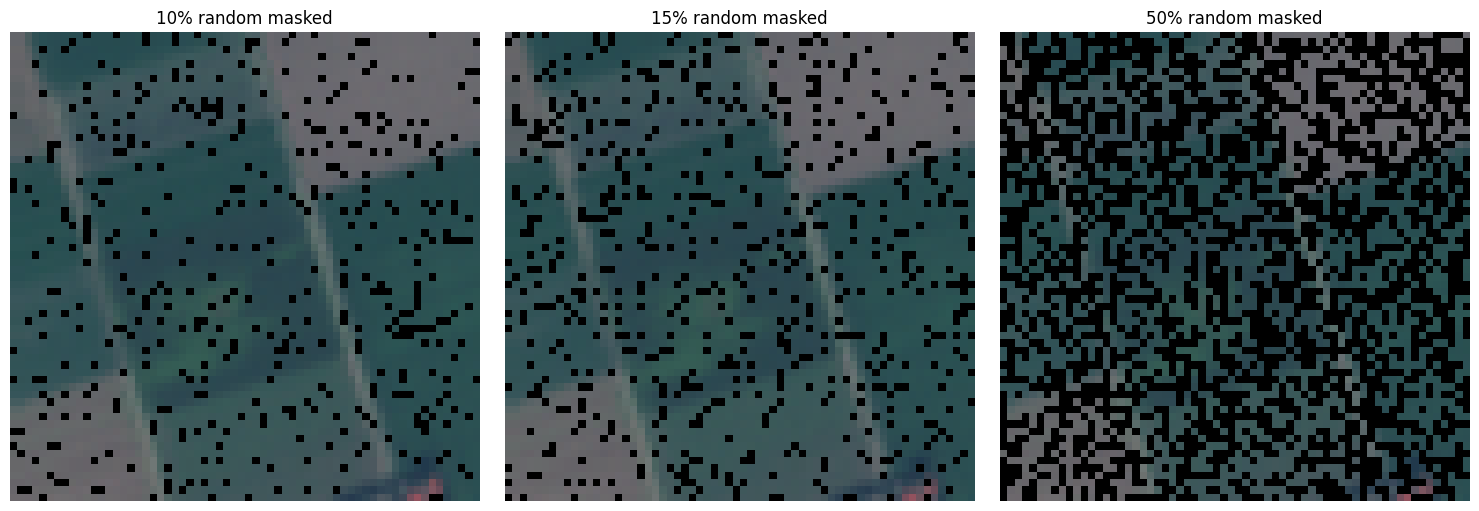


Testing with 10% of random pixels in the image masked:
Test Accuracy with 10% Random-Masked Images (CNN): 0.1131
Test Accuracy with 10% Random-Masked Images (ViT): 0.2889

Testing with 15% of random pixels in the image masked:
Test Accuracy with 15% Random-Masked Images (CNN): 0.1128
Test Accuracy with 15% Random-Masked Images (ViT): 0.2157

Testing with 50% of random pixels in the image masked:
Test Accuracy with 50% Random-Masked Images (CNN): 0.1194
Test Accuracy with 50% Random-Masked Images (ViT): 0.1135


In [26]:
# Datasets avec effets masquage aléatoire de l'image
mask_percent = [0.1, 0.15, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boucle sur les différents pourcentages de masque
for ax, mask in zip(axes, mask_percent):
    # Modifier l'image en appliquant un effet
    modified_image = d.apply_random_mask(image, mask)
    ax.imshow(modified_image)
    ax.axis('off')  # Masquer les axes
    ax.set_title(f"{int(mask*100)}% random masked")
plt.tight_layout()
plt.savefig(os.path.join(paths["images"], "random_masked_images.png"))
plt.show()

for mask in mask_percent:

    # Appliquer le masque au centre de l'image et sauvegarder l'image
    print(f"\nTesting with {int(mask*100)}% of random pixels in the image masked:")

    # Créer des dataloaders avec l'effet de masque centré
    random_mask_effects = {"random_mask": mask}
    cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=random_mask_effects)
    vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=random_mask_effects)
    acc_cnn_effects = accuracy(cnn_dataloader, model_cnn, device)
    acc_vit_effects = accuracy(vit_dataloader, model_vit, device)

    print(f"Test Accuracy with {int(mask*100)}% Random-Masked Images (CNN): {acc_cnn_effects:.4f}")
    print(f"Test Accuracy with {int(mask*100)}% Random-Masked Images (ViT): {acc_vit_effects:.4f}")

    log_result(f"{int(mask*100)}_random_masked", acc_cnn_effects, acc_vit_effects)


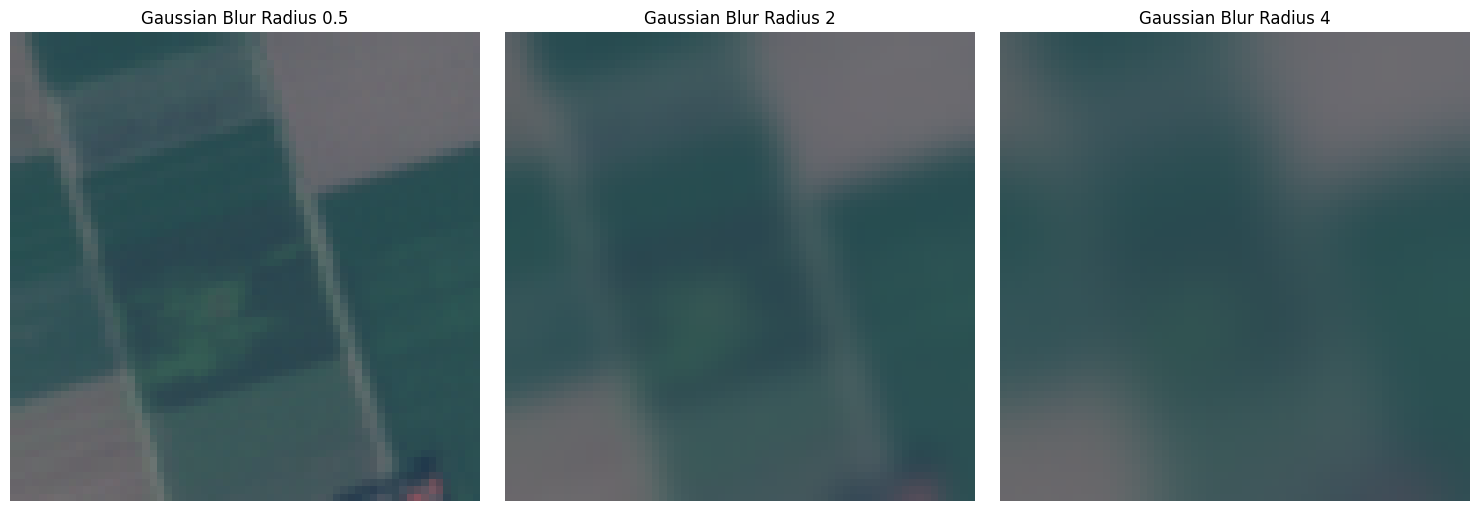

Test Accuracy with Gaussian Blur Radius 0.5 (CNN): 0.9719
Test Accuracy with Gaussian Blur Radius 0.5 (ViT): 0.9720
Test Accuracy with Gaussian Blur Radius 2 (CNN): 0.2256
Test Accuracy with Gaussian Blur Radius 2 (ViT): 0.4372
Test Accuracy with Gaussian Blur Radius 4 (CNN): 0.1406
Test Accuracy with Gaussian Blur Radius 4 (ViT): 0.3069


In [25]:
# Datasets avec effets masquage aléatoire de l'image
gaussian_blur_radii = [0.5, 2, 4]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boucle sur les différents radius de flou gaussien
for ax, radius in zip(axes, gaussian_blur_radii):
    # Modifier l'image en appliquant un effet
    modified_image = d.apply_blur(image, radius)
    ax.imshow(modified_image)
    ax.axis('off')  # Masquer les axes
    ax.set_title(f"Gaussian Blur Radius {radius}")

plt.tight_layout()
plt.savefig(os.path.join(paths["images"], "gaussian_blur_images.png"))
plt.show()

for radius in gaussian_blur_radii:

    # Créer des dataloaders avec l'effet de flou gaussien
    gaussian_blur_effects = {"gaussian_blur": radius}
    cnn_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "cnn", effects=gaussian_blur_effects)
    vit_dataloader = d.load_data(batch_size=batch_size,num_workers=num_workers, data_type="test", model_name = "vit", effects=gaussian_blur_effects)
    acc_cnn_effects = accuracy(cnn_dataloader, model_cnn, device)
    acc_vit_effects = accuracy(vit_dataloader, model_vit, device)

    print(f"Test Accuracy with Gaussian Blur Radius {radius} (CNN): {acc_cnn_effects:.4f}")
    print(f"Test Accuracy with Gaussian Blur Radius {radius} (ViT): {acc_vit_effects:.4f}")

    log_result(f"{radius}_gaussian_blur", acc_cnn_effects, acc_vit_effects)